# LDA

In [60]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='ticks')

F1_path = 'data/F1'
F3_path = 'data/F3'
F4_path = 'data/F4'
F5_path = 'data/F5'
os.makedirs(F5_path+"/LDA/figures", exist_ok=True)

## Setup

In [61]:
n_terms = 4000
n_topics = 15
max_iter = 5

OHCO = ['work_id','part_num','chap_num','para_num','sent_num','token_num']
PARAS = OHCO[:4]

LIB = pd.read_csv(f"{F1_path}/LIB.csv", index_col=OHCO[0])
TOKEN = pd.read_csv(f"{F4_path}/TOKEN.csv", index_col=OHCO, keep_default_na=False, na_values=[])

print(f"LIB: {len(LIB)} works")
print(f"TOKEN: {len(TOKEN):,} tokens")

LIB: 49 works
TOKEN: 283,960 tokens


In [62]:
PARAS_DF = (TOKEN[TOKEN.pos.str.match(r'^NNP?S?$', na = False)]
.groupby(PARAS).term_str
.apply(lambda x: ' '.join(x))
.to_frame()
.rename(columns={'term_str':'para_str'}))

In [63]:
PARAS_DF = PARAS_DF[PARAS_DF.para_str.str.strip() != '']
print(f"Paragraphs after noun filter: {len(PARAS_DF):,}")
PARAS_DF.head()

Paragraphs after noun filter: 3,569


para_str
work_id                       part_num chap_num para_num                                                   
accomplishment_of_predictions 1        1        1         account of the death mr partridge the almanack...
                                                2                         letter person honour written year
                                                3         lord obedience commands curiosity days partrid...
                                                4         discourse him lordship circumstance deathbed n...
address_to_jury               1        1        1         piece title expresses bill printer jury them c...

## Create vector space

In [64]:
tfv = CountVectorizer(max_features=n_terms, stop_words='english')
tf = tfv.fit_transform(PARAS_DF.para_str)
TERMS = tfv.get_feature_names_out()

print(f"Count matrix: {tf.shape}")
print(f"Vocabulary size: {len(TERMS)}")

Count matrix: (3569, 4000)
Vocabulary size: 4000


## Fit LDA

In [65]:
lda = LDA(n_components = n_topics, max_iter=max_iter, learning_offset=50., random_state=0)
lda.fit(tf)

LatentDirichletAllocation(learning_offset=50.0, max_iter=5, n_components=15,
                          random_state=0)

## Theta

In [66]:
THETA = pd.DataFrame(lda.transform(tf), index=PARAS_DF.index)
THETA.columns.name = 'topic_id'

THETA.sample(20).style.background_gradient(cmap="Blues")

## Phi

In [67]:
PHI = pd.DataFrame(lda.components_, columns = TERMS)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'

PHI.T.head().style.background_gradient(cmap="Blues")

topic_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
term_str,,,,,,,,,,,,,,,
abettors,0.066667,0.904275,0.066667,0.066667,1.229058,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,1.066666,0.066667,0.066667,0.066667
abhorrence,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,1.066667,0.066667,1.066667,0.066667,1.066667,0.066667,0.066667,0.066667,0.066667
abilities,0.066667,0.066667,3.728632,2.968410,2.558219,4.571316,0.066667,0.066667,3.809987,0.066667,4.590435,0.159574,0.066667,3.146761,0.066667
able,0.066667,0.066667,0.100030,0.066667,0.066667,2.066666,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,1.033303
abolishing,0.066667,0.066667,0.066667,0.066667,3.696010,0.066667,2.066667,0.066667,1.892307,0.066667,0.611683,0.066667,0.066667,0.066667,0.066667


## Top terms per topic

In [68]:
TOPICS = (PHI.stack().to_frame().rename(columns={0:'weight'})
.groupby('topic_id')
.apply(lambda x:
       x.weight.sort_values(ascending=False)
       .head(10)
       .reset_index()
       .drop('topic_id', axis=1)
       .term_str))

TOPICS['label'] = TOPICS.apply(lambda x: str(x.name) + ' ' + ' '.join(x[:7].astype('str')), axis = 1)

TOPICS

term_str,0,1,2,3,4,5,6,7,8,9,label
topic_id,,,,,,,,,,,
0,neverout,mr,miss,man,lord,smart,people,answ,life,use,0 neverout mr miss man lord smart people
1,feet,hand,time,yards,ground,day,high,air,left,animal,1 feet hand time yards ground day high
2,england,country,men,master,man,court,emperor,majesty,war,honour,2 england country men master man court emperor
3,time,man,persons,body,reason,friend,wit,country,master,yahoos,3 time man persons body reason friend wit
4,kingdom,wood,halfpence,country,patent,ireland,england,parliament,mr,majesty,4 kingdom wood halfpence country patent irelan...
5,money,man,mr,world,country,england,time,people,men,silver,5 money man mr world country england time
6,people,kingdom,time,nature,country,persons,year,tongue,ireland,nation,6 people kingdom time nature country persons year
7,smart,ld,miss,john,pray,madam,sir,colonel,sparkish,come,7 smart ld miss john pray madam sir
8,time,men,master,mind,wit,years,reader,thy,life,reason,8 time men master mind wit years reader


## Sort topics by document weight

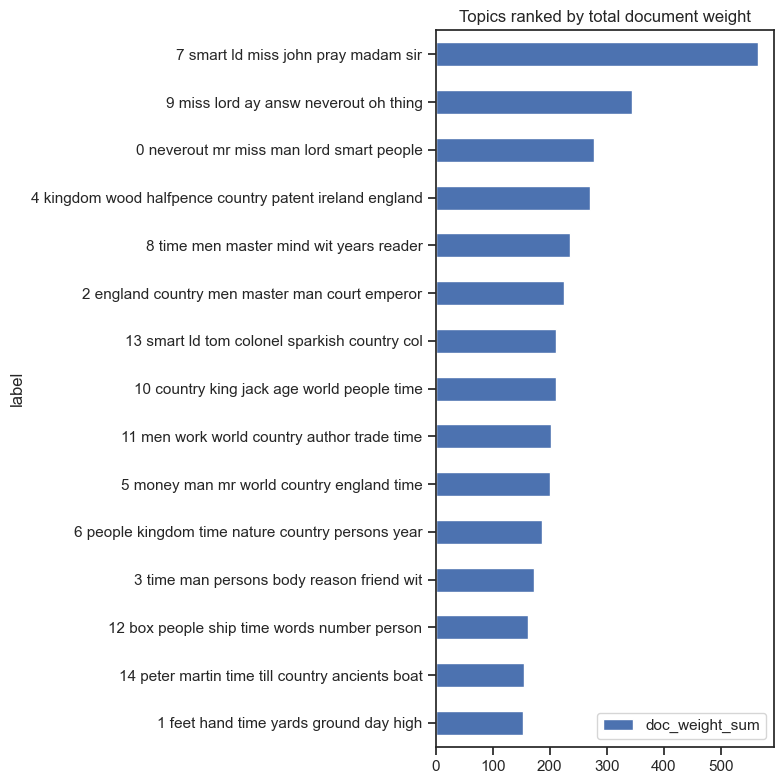

In [69]:
TOPICS['doc_weight_sum'] = THETA.sum()

(TOPICS.sort_values('doc_weight_sum', ascending = True)
                   .plot.barh(y='doc_weight_sum', x = 'label', figsize=(8,8),
                              title = 'Topics ranked by total document weight'))
plt.tight_layout()
plt.show()

## Topic concentration by broad genre

In [70]:
work_ids = THETA.index.get_level_values('work_id')
THETA_with_genre = THETA.copy()
THETA_with_genre['broad_genre'] = work_ids.map(LIB.broad_genre)

topic_cols = [t for t in range(n_topics)]
GENRES = THETA_with_genre.groupby('broad_genre')[topic_cols].mean().T
GENRES.index.name = 'topic_id'

GENRES['topterms'] = TOPICS[[i for i in range(10)]].apply(lambda x: " ".join(x), axis = 1)

GENRES.style.background_gradient(cmap="Blues",
                                 subset=[c for c in GENRES.columns if c != 'topterms'])

broad_genre,Essay,Political,Religious,Satire,Verse,topterms
topic_id,,,,,,
0,0.104575,0.059789,0.099699,0.080264,0.061643,neverout mr miss man lord smart people answ life use
1,0.034452,0.027221,0.039622,0.047187,0.034475,feet hand time yards ground day high air left animal
2,0.094444,0.059603,0.047909,0.062737,0.058957,england country men master man court emperor majesty war honour
3,0.071621,0.041772,0.087347,0.046870,0.053062,time man persons body reason friend wit country master yahoos
4,0.043536,0.241198,0.040960,0.046771,0.022754,kingdom wood halfpence country patent ireland england parliament mr majesty
5,0.046572,0.124890,0.078461,0.042971,0.023651,money man mr world country england time people men silver
6,0.081803,0.096981,0.053811,0.042017,0.049515,people kingdom time nature country persons year tongue ireland nation
7,0.028679,0.040839,0.013477,0.196205,0.093560,smart ld miss john pray madam sir colonel sparkish come
8,0.130527,0.033325,0.108359,0.058741,0.268852,time men master mind wit years reader thy life reason


## Heatmap

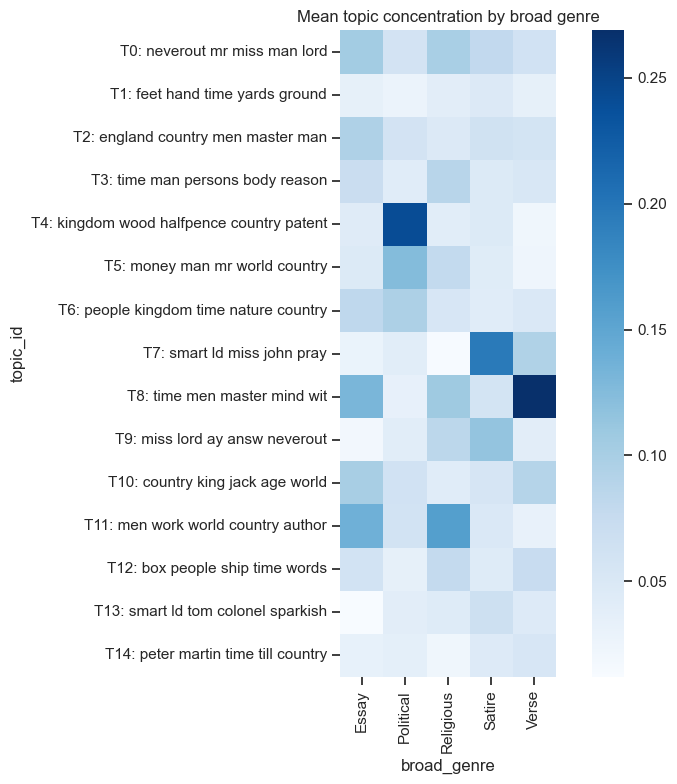

In [71]:
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(GENRES.drop(columns = 'topterms'),
            cmap="Blues",
            yticklabels=[f"T{i}: {' '.join(TOPICS.loc[i, [0,1,2,3,4]].tolist())}" for i in range(n_topics)],
            ax=ax,
            square = True)

ax.set_title('Mean topic concentration by broad genre')
plt.tight_layout()
plt.savefig(f"{F5_path}/LDA/figures/lda_topic_genre_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## Topic concentration by individual work

In [72]:
WORKS_TOPICS = THETA.groupby('work_id')[topic_cols].mean().T
WORKS_TOPICS.index.name = 'topic_id'

In [73]:
top_works_per_topic = WORKS_TOPICS.idxmax(axis=1).rename('top_work')
top_works_per_topic = top_works_per_topic.to_frame()
top_works_per_topic['top_terms'] = TOPICS[[i for i in range(7)]].apply(lambda x: ' '.join(x), axis = 1)
top_works_per_topic['title'] = top_works_per_topic.top_work.map(LIB.title)
top_works_per_topic

,top_work,top_terms,title
topic_id,,,
0,sermon_wisdom_of_this_world,neverout mr miss man lord smart people,On the Wisdom of This World
1,description_of_quilca,feet hand time yards ground day high,Swift's Description of Quilca
2,accomplishment_of_predictions,england country men master man court emperor,The Accomplishment of the First of Mr. Bickers...
3,prayer_for_stella_3,time man persons body reason friend wit,"Third Prayer for Stella (Nov 6, 1727)"
4,address_to_jury,kingdom wood halfpence country patent ireland ...,The Address to the Jury
5,injured_lady,money man mr world country england time,The Story of the Injured Lady
6,hints_essay_conversation,people kingdom time nature country persons year,Hints Towards an Essay on Conversation
7,polite_conversation_dialogue_2,smart ld miss john pray madam sir,Polite Conversation: Dialogue II
8,prayer_for_stella_1,time men master mind wit years reader,First Prayer for Stella


## Hierarchical clustering of topics

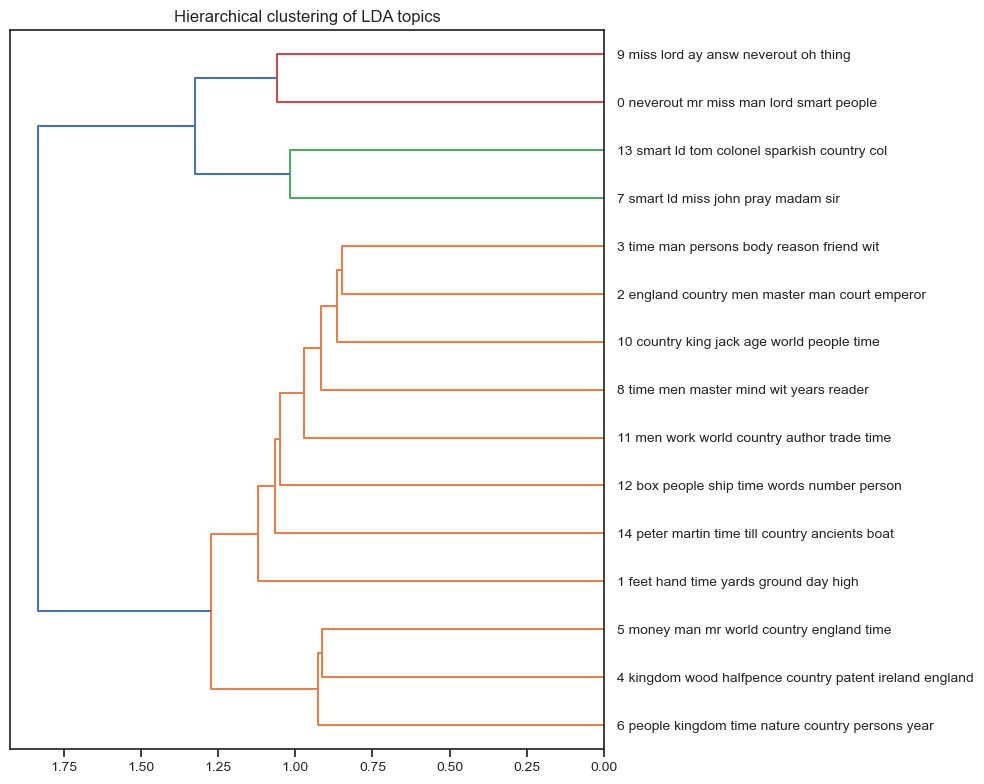

In [74]:
SIMS = pdist(normalize(PHI), metric = 'euclidean')
TREE = sch.linkage(SIMS, method = 'ward')

labels = TOPICS.label.tolist()

fig, ax = plt.subplots(figsize=(10,8))
sch.dendrogram(TREE, labels=labels, orientation='left')
plt.tick_params(axis='both', which='major', labelsize=10)
plt.title('Hierarchical clustering of LDA topics')
plt.tight_layout()
plt.savefig(f"{F5_path}/LDA/figures/lda_topic_dendrogram.png", dpi=300, bbox_inches='tight')
plt.show()

## Save

In [75]:
THETA.to_csv(f"{F5_path}/LDA/LDA_THETA.csv")
PHI.to_csv(f"{F5_path}/LDA/LDA_PHI.csv")
TOPICS.to_csv(f"{F5_path}/LDA/LDA_TOPICS.csv")
GENRES.to_csv(f"{F5_path}/LDA/LDA_topic_by_genre.csv")
WORKS_TOPICS.to_csv(f"{F5_path}/LDA/LDA_topic_by_work.csv")